# TSF vs CPS — dados discretos reais

Comparação entre o **Two-Stage Forecaster (TSF)** do `tinyshift` e o **Conformal Predictive System (CPS)** do `tinyconformal` em M5 e UCI Bike Sharing. Ambos são avaliados fora da amostra, com alvos inteiros e sem dados sintéticos.

In [1]:
from importlib.metadata import version
from pathlib import Path
from time import perf_counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from lightgbm import LGBMRegressor
from mlforecast import MLForecast
from sklearn.ensemble import HistGradientBoostingRegressor

from tinyshift.forecasting import (
    NegativeBinomialFamily,
    TwoStageForecasterWrapper,
    WeibullFamily,
)
from tinyconformal.series import (
    ContinuousTimeSeriesConformalPredictiveSystem,
    DiscreteTimeSeriesConformalPredictiveSystem,
)

SEED = 42
H = 14
N_WINDOWS = 5
LEVEL = 0.90
DATA_DIR = Path("data/tsf_cps")
DATA_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

print({"tinyshift": version("tinyshift"), "tinyconformal": version("tinyconformal")})

{'tinyshift': '1.7.7', 'tinyconformal': '0.5.4'}


In [2]:
def make_forecaster(freq, lags):
    model = LGBMRegressor(
        n_estimators=120, learning_rate=0.05, num_leaves=15,
        verbosity=-1, random_state=SEED, n_jobs=1,
    )
    return MLForecast(models={"LGBM": model}, freq=freq, lags=lags)


def fit_tsf(train, freq, lags, family, h=H, n_windows=N_WINDOWS):
    model = TwoStageForecasterWrapper(make_forecaster(freq, lags), distribution=family)
    tic = perf_counter()
    model.fit(train, h=h, n_windows=n_windows, refit=True)
    fit_seconds = perf_counter() - tic
    tic = perf_counter()
    forecast = model.predict_distribution(h=h)
    predict_seconds = perf_counter() - tic
    return model, forecast, fit_seconds, predict_seconds


def fit_cps(train, freq, lags, discrete, h=H, n_windows=N_WINDOWS):
    cls = (DiscreteTimeSeriesConformalPredictiveSystem if discrete
           else ContinuousTimeSeriesConformalPredictiveSystem)
    model = cls(
        learner=make_forecaster(freq, lags),
        dispersion_learner=HistGradientBoostingRegressor(
            max_iter=80, max_leaf_nodes=8, random_state=SEED
        ),
        horizon=h, n_windows=n_windows, alpha=1-LEVEL,
    )
    tic = perf_counter()
    model.fit(train, n_jobs=1)
    fit_seconds = perf_counter() - tic
    tic = perf_counter()
    forecast = model.predict_distribution(h=h)
    predict_seconds = perf_counter() - tic
    return model, forecast, fit_seconds, predict_seconds


def prediction_table(forecast, test, level=LEVEL):
    base = forecast.to_frame().copy()
    intervals = forecast.interval(level)
    quantiles = forecast.ppf([0.5])
    out = base.merge(test[["unique_id", "ds", "y"]], on=["unique_id", "ds"], validate="one_to_one")
    # APIs preservam a ordem do painel e nomeiam explicitamente os outputs.
    lo_col = next(c for c in intervals if "-lo-" in c)
    hi_col = next(c for c in intervals if "-hi-" in c)
    median_col = next(c for c in quantiles if "-q-50" in c)
    out["lower"] = intervals[lo_col].to_numpy()
    out["upper"] = intervals[hi_col].to_numpy()
    out["median"] = quantiles[median_col].to_numpy()
    return out


def metrics(table, method, dataset, fit_seconds, predict_seconds, level=LEVEL):
    y = table.y.to_numpy(float)
    lo, hi, pred = (table[c].to_numpy(float) for c in ["lower", "upper", "median"])
    alpha = 1-level
    covered = (y >= lo) & (y <= hi)
    winkler = (hi-lo) + (2/alpha)*(lo-y)*(y < lo) + (2/alpha)*(y-hi)*(y > hi)
    return {
        "dataset": dataset, "method": method,
        "RMSE_mediana": np.sqrt(np.mean((y-pred)**2)),
        "MAE_mediana": np.mean(np.abs(y-pred)),
        "cobertura_90": covered.mean(), "largura_media_90": np.mean(hi-lo),
        "Winkler_90": np.mean(winkler), "fit_s": fit_seconds,
        "predict_s": predict_seconds, "n_teste": len(y),
    }


def plot_intervals(tables, title):
    fig, axes = plt.subplots(len(tables), 1, figsize=(13, 3.6*len(tables)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, (name, tab) in zip(axes, tables.items()):
        one = tab[tab.unique_id == tab.unique_id.iloc[0]]
        ax.plot(one.ds, one.y, "o-", color="black", label="observado", ms=3)
        ax.plot(one.ds, one["median"], color="C0", label="mediana")
        ax.fill_between(one.ds, one.lower, one.upper, alpha=.25, label="intervalo 90%")
        ax.set_title(name); ax.legend(ncol=3)
    fig.suptitle(title, y=1.01); plt.tight_layout()


def temporal_split(df, h=H):
    df = df.sort_values(["unique_id", "ds"]).reset_index(drop=True)
    test = df.groupby("unique_id", group_keys=False).tail(h)
    train = df.drop(test.index).reset_index(drop=True)
    return train, test.reset_index(drop=True)

In [3]:
M5_URL = "https://www.kaggle.com/competitions/m5-forecasting-accuracy/data"
M5_MIRROR = "https://huggingface.co/datasets/kashif/M5/resolve/main/sales_train_evaluation.csv"
BIKE_URL = "https://raw.githubusercontent.com/udacity/deep-learning/master/first-neural-network/Bike-Sharing-Dataset/hour.csv"


def load_m5(n_series=5, n_days=700):
    """Baixa a competição oficial (aceite das regras/login Kaggle pode ser necessário)."""
    target = DATA_DIR / "m5" / "sales_train_evaluation.csv"
    if not target.exists():
        import kagglehub
        try:
            downloaded = Path(kagglehub.competition_download("m5-forecasting-accuracy"))
            candidates = list(downloaded.rglob("sales_train_evaluation.csv"))
        except Exception as exc:
            warnings.warn(f"Kaggle indisponível ({type(exc).__name__}); usando espelho público Hugging Face.")
            candidates = []
        source = candidates[0] if candidates else M5_MIRROR
        target.parent.mkdir(parents=True, exist_ok=True)
        if isinstance(source, Path):
            target.write_bytes(source.read_bytes())
        else:
            from urllib.request import urlretrieve
            urlretrieve(source, target)
    wide = pd.read_csv(target, nrows=n_series)
    day_cols = [c for c in wide if c.startswith("d_")][-n_days:]
    long = wide[["id", *day_cols]].melt("id", var_name="day", value_name="y")
    long["ds"] = pd.Timestamp("2011-01-29") + pd.to_timedelta(long.day.str[2:].astype(int)-1, unit="D")
    return long.rename(columns={"id": "unique_id"})[["unique_id", "ds", "y"]].astype({"y": int})


def load_bike():
    raw = pd.read_csv(BIKE_URL)
    raw["ds"] = pd.to_datetime(raw.dteday) + pd.to_timedelta(raw.hr, unit="h")
    # Maior trecho horário contíguo: não preenche nem sintetiza horas ausentes.
    raw = raw.sort_values("ds")
    run = raw.ds.diff().ne(pd.Timedelta(hours=1)).cumsum()
    raw = raw[run.eq(run.value_counts().idxmax())].tail(24*180)
    return pd.DataFrame({"unique_id": "CapitalBikeshare", "ds": raw.ds, "y": raw.cnt.astype(int)})


datasets = {"M5 (5 itens)": load_m5(), "UCI Bike Sharing": load_bike()}
for name, frame in datasets.items():
    print(name, frame.shape, frame.ds.min(), frame.ds.max(), "inteiros:", np.all(frame.y == np.floor(frame.y)))

M5 (5 itens) (3500, 3) 2014-06-23 00:00:00 2016-05-22 00:00:00 inteiros: True
UCI Bike Sharing (4320, 3) 2012-05-02 01:00:00 2012-10-29 00:00:00 inteiros: True


## Benchmark temporal

A última janela é teste; todas as janelas anteriores são treino/calibração. O mesmo LightGBM, lags, horizonte e número de janelas são usados por TSF e CPS.

In [4]:
results, predictions = [], {}
for dataset_name, df in datasets.items():
    freq = "MS" if dataset_name == "AirPassengers" else ("h" if "Bike" in dataset_name else "D")
    lags = [1, 12] if freq == "MS" else ([1, 24, 168] if freq == "h" else [1, 7, 28])
    train, test = temporal_split(df)

    tsf, tsf_fc, tsf_fit, tsf_pred = fit_tsf(train, freq, lags, NegativeBinomialFamily())
    cps, cps_fc, cps_fit, cps_pred = fit_cps(train, freq, lags, discrete=True)
    tsf_tab = prediction_table(tsf_fc, test)
    cps_tab = prediction_table(cps_fc, test)
    predictions[(dataset_name, "TSF")] = tsf_tab
    predictions[(dataset_name, "CPS")] = cps_tab
    results += [
        metrics(tsf_tab, "TSF", dataset_name, tsf_fit, tsf_pred),
        metrics(cps_tab, "CPS", dataset_name, cps_fit, cps_pred),
    ]

resultados = pd.DataFrame(results)
display(resultados.round(4))
display(resultados.pivot(index="dataset", columns="method",
                         values=["RMSE_mediana", "cobertura_90", "largura_media_90", "Winkler_90", "fit_s"]).round(4))

,dataset,method,RMSE_mediana,MAE_mediana,cobertura_90,largura_media_90,Winkler_90,fit_s,predict_s,n_teste
0,M5 (5 itens),TSF,1.3093,0.9429,1.0000,4.0143,4.0143,0.4900,0.0243,70
1,M5 (5 itens),CPS,1.6345,1.2714,0.7571,2.8429,7.9857,0.6412,0.0288,70
2,UCI Bike Sharing,TSF,201.6303,182.6429,0.2857,356.5714,1335.1429,0.3565,0.0240,14
3,UCI Bike Sharing,CPS,219.0263,198.2143,0.2857,215.8571,2805.8571,0.5277,0.0291,14


RMSE_mediana           cobertura_90         largura_media_90  \
method                    CPS       TSF          CPS     TSF              CPS   
dataset                                                                         
M5 (5 itens)           1.6345    1.3093       0.7571  1.0000           2.8429   
UCI Bike Sharing     219.0263  201.6303       0.2857  0.2857         215.8571   

                           Winkler_90              fit_s          
method                 TSF        CPS        TSF     CPS     TSF  
dataset                                                           
M5 (5 itens)        4.0143     7.9857     4.0143  0.6412  0.4900  
UCI Bike Sharing  356.5714  2805.8571  1335.1429  0.5277  0.3565

## Visualização e síntese

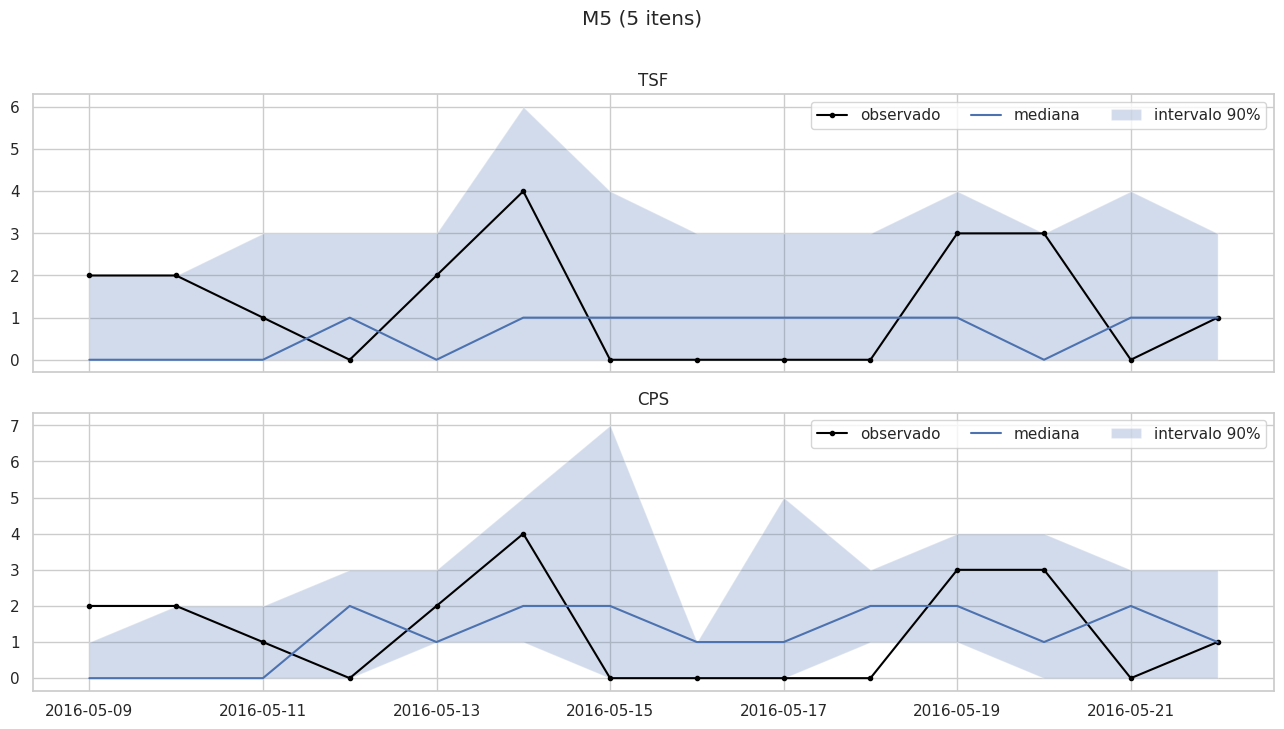

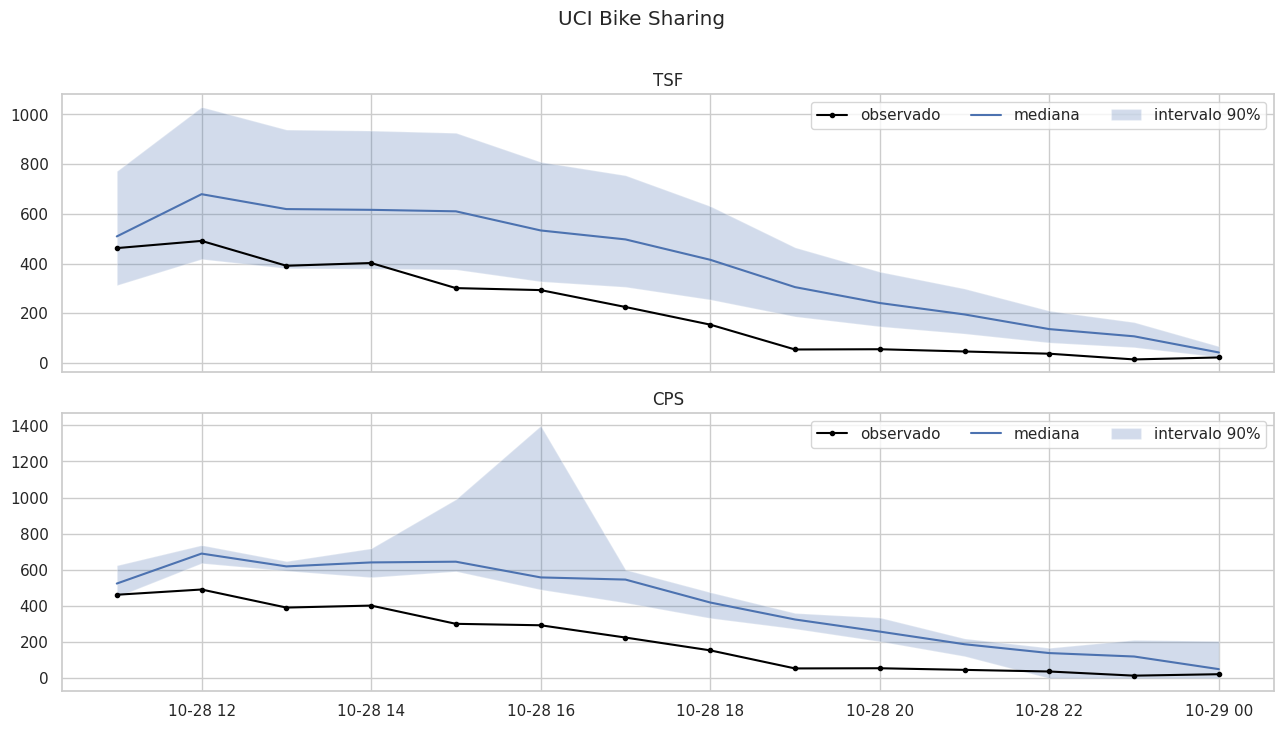

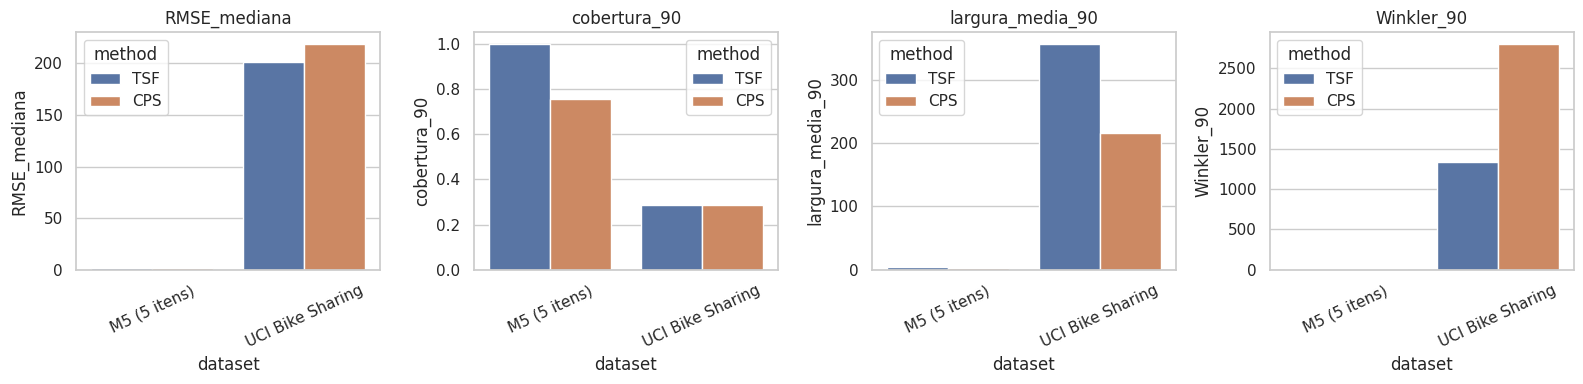

In [5]:
for dataset_name in datasets:
    plot_intervals(
        {method: predictions[(dataset_name, method)] for method in ["TSF", "CPS"]},
        dataset_name,
    )

metric_cols = ["RMSE_mediana", "cobertura_90", "largura_media_90", "Winkler_90"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, metric in zip(axes, metric_cols):
    sns.barplot(resultados, x="dataset", y=metric, hue="method", ax=ax)
    ax.tick_params(axis="x", rotation=25); ax.set_title(metric)
plt.tight_layout()

In [6]:
def winners(frame):
    rows = []
    for dataset, part in frame.groupby("dataset"):
        target = 0.90
        rows.append({
            "dataset": dataset,
            "menor_RMSE": part.loc[part.RMSE_mediana.idxmin(), "method"],
            "cobertura_mais_próxima_90%": part.loc[(part.cobertura_90-target).abs().idxmin(), "method"],
            "menor_Winkler": part.loc[part.Winkler_90.idxmin(), "method"],
            "fit_mais_rápido": part.loc[part.fit_s.idxmin(), "method"],
        })
    return pd.DataFrame(rows)

display(winners(resultados))
print("Leitura: cobertura isolada não premia intervalos excessivamente largos; por isso Winkler é a métrica principal de intervalo.")

,dataset,menor_RMSE,cobertura_mais_próxima_90%,menor_Winkler,fit_mais_rápido
0,M5 (5 itens),TSF,TSF,TSF,TSF
1,UCI Bike Sharing,TSF,TSF,TSF,TSF


Leitura: cobertura isolada não premia intervalos excessivamente largos; por isso Winkler é a métrica principal de intervalo.


## Reprodutibilidade e ressalvas

- Não há geração de dados sintéticos. As URLs/fontes estão explícitas no notebook.
- Resultados dependem de hardware, versões e da janela temporal escolhida.
- M5 exige aceitar as regras da competição e autenticar o Kaggle uma única vez.
- TSF é paramétrico; CPS usa resíduos conformais empíricos. Nenhum método domina necessariamente em todos os critérios.